### Artificial Neural Networking using PyTorch (Dropout, Batch Normalization, L2 Regularization Optimized)

- Dataset: Fashion MNIST from Kaggle
  - 70,000 Training data
  - Grayscale
  - Each has dimension of 28 \* 28


#### Architectural Overview

Input Layer:

- Total number of features - 784
- Hidden layers:
  - Layer 1:
    - Number of Nodes: 128
    - Activation Function: ReLU
  - Layer 2:
    - Number of nodes: 64
    - Activation Function: ReLU
  - Will apply Dropouts for optimization
- Output Layer:
  - Number of nodes: 10
  - Activation function: SoftMax (As we are dealing with multiclass classification problem)

#### Workflow

- Creating DataLoader Objects
- Training Loop
- Evaluation


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torch.optim as optim 
import matplotlib.pyplot as plt


In [3]:
torch.manual_seed(42)

In [4]:
# Check for GPU
# For apple silicon chip, use mps, otherwise use cuda (google colab)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [5]:
df = pd.read_csv('dataset/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


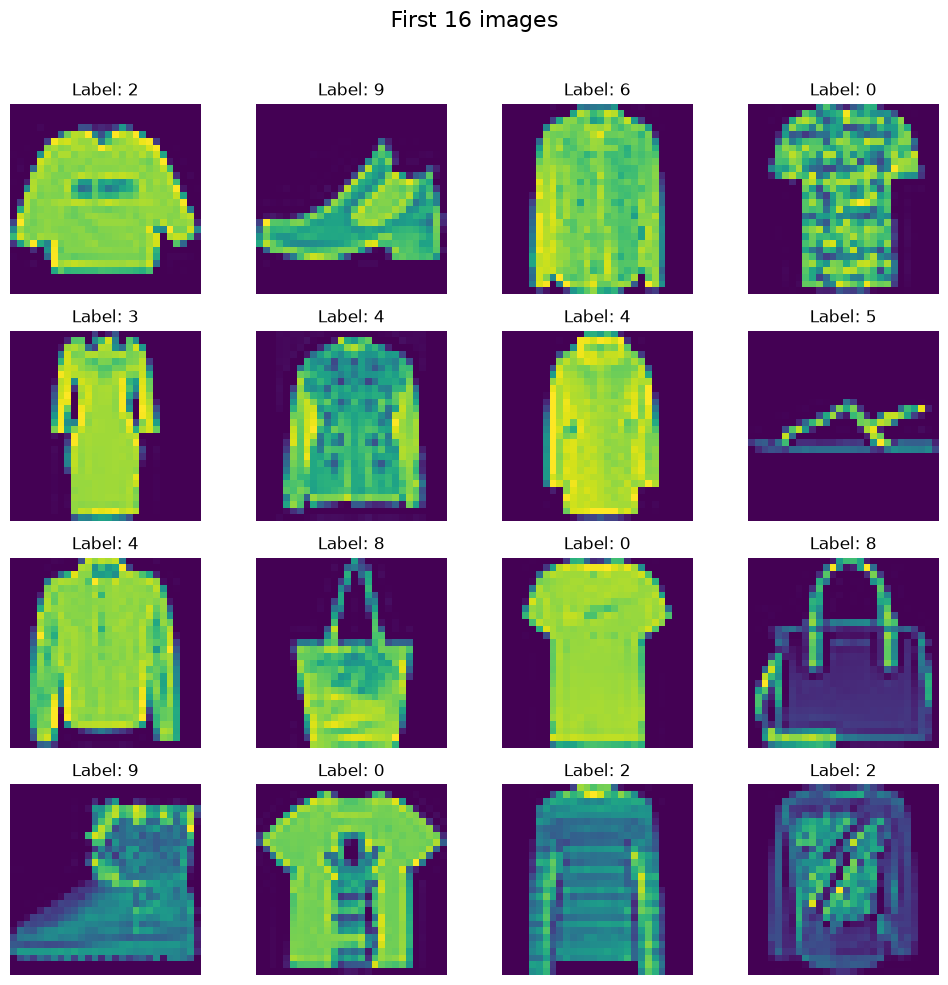

In [6]:
# Create 4x4 (16 images) grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 images", fontsize=16)

# plot the first 16 images from the dataset
for i, ax, in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28) # reshape to 28*28
  ax.imshow(img) # display in grayscale
  ax.axis('off') # remove axis for cleaner look
  ax.set_title(f"Label: {df.iloc[i, 0]}") # show the label
  
plt.tight_layout(rect=[0, 0, 1, 0.96]) # adjust layout to fit the title
plt.show()

In [7]:
# train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# scaling the features
# in the dataset, the pixel values are within 0 to 255. 
# It is better for neural networking to make the traning values
# between 0 to 1. That's why diving all by 255.
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
# Create CustomDataset Class
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)
    
  def __len__(self):
    return len(self.features)
  
  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [11]:
# Create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [12]:
test_dataset = CustomDataset(X_test, y_test)

In [13]:
# Create train and test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
# Define NN class
# Do not need to add Softmax for output layer
# In pytoch it is added by default
# Using Dropout optimization
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
      nn.Linear(num_features, 128),
      nn.BatchNorm1d(128),
      nn.ReLU(),
      nn.Dropout(p=0.3),
      nn.Linear(128, 64),
      nn.BatchNorm1d(64),
      nn.ReLU(),
      nn.Dropout(p=0.3),
      nn.Linear(64, 10)
    )
    
  def forward(self, x):
    return self.model(x)

In [15]:
epochs = 100
learning_rate = 0.1

In [16]:
# Instantiate the model
model = MyNN(X_train.shape[1])

# Run the model in GPU
model.to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)



In [17]:
# Training Loop
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    # move data to GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    
    # forward pass
    outputs = model(batch_features)
    
    # calculate loss
    loss = criterion(outputs, batch_labels)
    
    # backpropagation
    optimizer.zero_grad()
    loss.backward()
    
    # gradients update
    optimizer.step()
    
    total_epoch_loss = total_epoch_loss + loss.item()
  
  avg_loss = total_epoch_loss / len(train_loader)
  print(f"Epoch: {epoch + 1}, Loss: {avg_loss}")
    

Epoch: 1, Loss: 0.6265809819996357
Epoch: 2, Loss: 0.4928831786115964
Epoch: 3, Loss: 0.4575098012586435
Epoch: 4, Loss: 0.43367416443427403
Epoch: 5, Loss: 0.41746360425651075
Epoch: 6, Loss: 0.4048205816845099
Epoch: 7, Loss: 0.3944236808816592
Epoch: 8, Loss: 0.3868011025985082
Epoch: 9, Loss: 0.3745436135828495
Epoch: 10, Loss: 0.3723326070358356
Epoch: 11, Loss: 0.3649866507748763
Epoch: 12, Loss: 0.36162552632391454
Epoch: 13, Loss: 0.3517713617483775
Epoch: 14, Loss: 0.3482197345793247
Epoch: 15, Loss: 0.34316916432976724
Epoch: 16, Loss: 0.3366626870657007
Epoch: 17, Loss: 0.3358462312569221
Epoch: 18, Loss: 0.33293966139853
Epoch: 19, Loss: 0.3310722675298651
Epoch: 20, Loss: 0.32943966676294806
Epoch: 21, Loss: 0.3227487936715285
Epoch: 22, Loss: 0.32162945522367953
Epoch: 23, Loss: 0.3183090126911799
Epoch: 24, Loss: 0.3205702704017361
Epoch: 25, Loss: 0.3126984076400598
Epoch: 26, Loss: 0.31334596720834573
Epoch: 27, Loss: 0.31267338917404414
Epoch: 28, Loss: 0.311196297799

In [18]:
# Set model to eval mode
# this function turns the model into evaluation mode. 
model.eval()
# it prevents the model from dropping off the neurons which sometimes happens in training over a dataset. 

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [19]:
# evaluation code
# will use test dataset for evaluation the model
total = 0
correct = 0

with torch.no_grad(): # as we do not need gradient while predicting 
  for batch_features, batch_labels in test_loader:
    # move data to GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    print(f"Outputs: {outputs}")
    _, predicted = torch.max(outputs, 1)
    print(f"Predicted: {predicted}")
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()
  
print(correct / total)

Outputs: tensor([[-1.5106e+00, -1.3607e+00, -4.0315e+00, -1.4371e+00, -4.8947e+00,
          1.9107e+00, -3.4761e+00,  1.2181e+01,  1.0138e+00,  1.5278e+00],
        [-6.7260e-02, -4.3627e+00, -4.1400e+00, -4.4286e+00, -4.4798e+00,
          1.2881e+00, -2.0820e+00,  1.1760e+00,  1.5134e+01,  1.8070e+00],
        [-1.3996e+00, -4.9565e+00, -3.4680e+00, -3.9249e+00, -1.0806e+00,
          6.9415e-01, -2.7624e-01,  7.1761e-01,  1.1793e+01,  1.7485e+00],
        [-5.2489e+00,  3.9399e-01, -1.7378e+00, -5.2450e+00,  1.9909e+00,
          1.3710e+01,  8.8009e-01, -2.8260e+00, -8.2708e+00,  5.9632e+00],
        [-2.9544e+00, -2.4963e+00, -5.9305e+00, -2.5819e+00, -4.9362e+00,
          3.6740e+00, -2.2558e+00,  4.8742e+00, -3.8423e+00,  1.6014e+01],
        [ 1.3127e+00,  1.3362e+01, -1.5960e+00,  1.4916e+00, -9.6073e-01,
         -3.5754e+00, -8.1498e-02, -6.1991e+00, -2.6504e+00, -1.3040e+00],
        [-1.4226e+00, -1.7600e-01,  1.0625e+01, -3.7820e+00,  5.8469e+00,
         -3.5668e+00,  

In [20]:
total = 0
correct = 0

with torch.no_grad(): # as we do not need gradient while predicting 
  for batch_features, batch_labels in train_loader:
    # move data to GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    _, predicted = torch.max(outputs, 1)
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()
  
print(correct / total)

0.9471666666666667
